# 项目：用逻辑回归预测泰坦尼克号幸存情况

## 分析目标

此数据分析报告的目的是，基于泰坦尼克号乘客的性别和船舱等级等属性，对幸存情况进行逻辑回归分析，从而能利用得到的模型，对未知幸存情况的乘客，根据属性预测是否从沉船事件中幸存。

## 简介

> 泰坦尼克号（英语：RMS Titanic）是一艘奥林匹克级邮轮，于1912年4月首航时撞上冰山后沉没。泰坦尼克号是同级的3艘超级邮轮中的第2艘，与姐妹船奥林匹克号和不列颠号为白星航运公司的乘客们提供大西洋旅行。

> 泰坦尼克号由位于北爱尔兰贝尔法斯特的哈兰·沃尔夫船厂兴建，是当时最大的客运轮船，由于其规模相当一艘现代航空母舰，因而号称“上帝也沉没不了的巨型邮轮”。在泰坦尼克号的首航中，从英国南安普敦出发，途经法国瑟堡-奥克特维尔以及爱尔兰昆士敦，计划横渡大西洋前往美国纽约市。但因为人为错误，于1912年4月14日船上时间夜里11点40分撞上冰山；2小时40分钟后，即4月15日凌晨02点20分，船裂成两半后沉入大西洋，死亡人数超越1500人，堪称20世纪最大的海难事件，同时也是最广为人知的海难之一。

数据集包括两个数据表：`titianic_train.csv`和`titanic_test.csv`。

`titianic_train.csv`记录了超过八百位泰坦尼克号乘客在沉船事件后的幸存情况，以及乘客的相关信息，包括所在船舱等级、性别、年龄、同乘伴侣/同胞数量、同乘父母/孩子数量，等等。

`titanic_test.csv`只包含乘客（这些乘客不在`titianic_train.csv`里）相关信息，此文件可以被用于预测乘客是否幸存。

`titianic_train.csv`每列的含义如下：
- PassengerId：乘客ID
- survival：是否幸存
   - 0	否
   - 1	是
- pclass：船舱等级
   - 1	一等舱
   - 2	二等舱
   - 3  三等舱
- sex：性别
- Age：年龄
- sibsp：同乘伴侣/同胞数量
- parch：同乘父母/孩子数量
- ticket：船票号
- fare：票价金额
- cabin：船舱号
- embarked：登船港口
   - C  瑟堡
   - Q  皇后镇
   - S  南安普敦
   
   
`titianic_test.csv`每列的含义和上面相同，但不具备survival变量的数据，即是否幸存。

引入数据读取、清洗、可视化所需要的库。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 读取数据

使用pandas的read_csv方法，读取数据集titanic_train.csv，并将获得的DataFrame赋值给原始数据变量original_titanic_train。

In [2]:
original_titanic_train = pd.read_csv('titanic_train.csv')
original_titanic_train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


## 数据评估和清洗

在评估和清洗前，我们先创建一个变量cleaned__titanic_train，并将原始数据original_titanic_train复制的副本赋值给它，用来区分原始数据和清洗后的数据，之后所有的清洗步骤均在cleaned__titanic_train上操作。

In [3]:
cleaned_titanic_train = original_titanic_train.copy()
cleaned_titanic_train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


数据评估主要分为两个方向，即数据结构和数据内容。  
评估数据结构主要看数据的整洁度，即是否“每行为一个观察值，每列为一个变量，每个单元格为一个值”。  
评估数据内容主要看数据的干净度，即是否有空缺数据、重复数据、不一致数据、无效和错误数据。

### 处理数据整洁度

经观察数据集cleaned__titanic_train符合“每行为一个观察值，每列为一个变量，每个单元格为一个值”，不需要对数据结构进行清洗。

### 处理数据干净度

首先调用info方法对数据内容的概况进行了解。

In [4]:
cleaned_titanic_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


有info方法得知，数据集cleaned__titanic_train总共有891行观察值，其中变量Age、Cabin、Embarked有缺失值，将在后续进行评估和清洗。  
另外PassengerId表示乘客ID，数据类型不应该是整数而应该是字符串，需要进行转换。  
而变量Survived、Pclass、Sex、Embarked为分类数据，可以转化为Category。

In [5]:
cleaned_titanic_train['PassengerId'] = cleaned_titanic_train['PassengerId'].astype('str')
cleaned_titanic_train['Survived'] = cleaned_titanic_train['Survived'].astype('category')
cleaned_titanic_train['Pclass'] = cleaned_titanic_train['Pclass'].astype('category')
cleaned_titanic_train['Sex'] = cleaned_titanic_train['Sex'].astype('category')
cleaned_titanic_train['Embarked'] = cleaned_titanic_train['Embarked'].astype('category')

In [6]:
cleaned_titanic_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    object  
 1   Survived     891 non-null    category
 2   Pclass       891 non-null    category
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          714 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    object  
 11  Embarked     889 non-null    category
dtypes: category(4), float64(2), int64(2), object(4)
memory usage: 59.8+ KB


#### 处理缺失数据

由info方法得知，Age、Cabin、Embarked变量有缺失值。

In [7]:
cleaned_titanic_train.query('Age.isnull()')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S


以上可知，Age（年龄）变量为缺失值的观察值一共有177行，由于这些观察值较多，且其他列的数据较为完整，仍然能为分析提供价值，因此最好是保留这些行。但由于Age（年龄）变量是后面逻辑回归分析需要使用到的重要变量，不能有缺失值，因此我们将使用平均值对其填充。

In [8]:
cleaned_titanic_train['Age'] = cleaned_titanic_train['Age'].fillna(cleaned_titanic_train['Age'].mean())

In [9]:
cleaned_titanic_train['Age'].isnull().sum()

0

In [10]:
cleaned_titanic_train.query('Cabin.isnull()')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,29.699118,0,0,330877,8.4583,NaN,Q
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.000000,3,1,349909,21.0750,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.000000,0,0,SOTON/OQ 392076,7.0500,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.000000,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,NaN,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,NaN,S


以上可知，Cabin（船舱号）变量为缺失值的观察值一共有687行，占了绝大多数。而船舱号不是影响生还概率的因素，不会被在后续作为逻辑回归分析的变量使用，因此可以保留这些行。

In [11]:
cleaned_titanic_train.query('Embarked.isnull()')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


由以上可知，Embarked（登陆港口）变量为缺失值的观察值一共有2行，而且这两行中的其他变量都是完整的，可以为分析提供价值。并且登陆港口并不是影响生还概率的因素，不会在后续逻辑回归分析中作为变量只用，因此可以保留这两行观察值。

#### 处理重复数据

由数据中各变量的意义可知，PassengerId（乘客ID）作为表示乘客身份的唯一标识，不能有重复值。因此需要检查PassengerId是否有重复值。

In [12]:
cleaned_titanic_train['PassengerId'].duplicated().sum()

0

调用sum函数求和后，PassengerId变量的重复值个数为0，不存在重复值。

#### 处理不一致数据

检查所有分类变量，查看是否存在不同值指代同一目标的情况。

In [13]:
cleaned_titanic_train['Survived'].value_counts()

0    549
1    342
Name: Survived, dtype: int64

In [14]:
cleaned_titanic_train['Pclass'].value_counts()

3    491
1    216
2    184
Name: Pclass, dtype: int64

In [15]:
cleaned_titanic_train['Sex'].value_counts()

male      577
female    314
Name: Sex, dtype: int64

In [16]:
cleaned_titanic_train['Embarked'].value_counts()

S    644
C    168
Q     77
Name: Embarked, dtype: int64

从以上输出结果来看，不存在不一致数据。

#### 处理无效和错误数据

调用describe函数，查看数值变量的总体统计信息。

In [17]:
cleaned_titanic_train.describe()

,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000
mean,29.699118,0.523008,0.381594,32.204208
std,13.002015,1.102743,0.806057,49.693429
min,0.420000,0.000000,0.000000,0.000000
25%,22.000000,0.000000,0.000000,7.910400
50%,29.699118,0.000000,0.000000,14.454200
75%,35.000000,1.000000,0.000000,31.000000
max,80.000000,8.000000,6.000000,512.329200


从以上信息来看，不存在脱离现实意义的值。

## 整理数据

根据题目，分析的目的是基于泰坦尼克号乘客的性别和船舱等级等属性，对幸存情况进行逻辑回归分析，从而能利用得到的模型，对未知幸存情况的乘客，根据属性预测是否从沉船事件中幸存。  
数据集中包含SibSp（同乘伴侣/同胞数量）和Parch（同乘父母/孩子的数量），可以得出同乘的家人数量，我们可以创建一个变量来表示这个数据。

In [18]:
cleaned_titanic_train['Family'] = cleaned_titanic_train['SibSp'] + cleaned_titanic_train['Parch']
cleaned_titanic_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0


## 探索数据

在逻辑回归分析之前，我们可以使用可视化观察数值变量的分布，及各变量与是否幸存的相关性，为后续分析提供方向。

In [19]:
#设置调色盘
sns.set_palette('pastel')

### 幸存比例

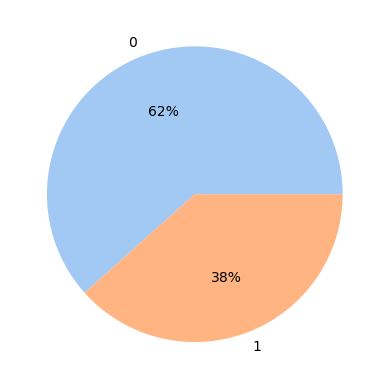

In [20]:
survived_count = cleaned_titanic_train['Survived'].value_counts()
survived_label = survived_count.index
plt.pie(survived_count, labels = survived_label, autopct = '%.0f%%')
plt.show()

由以上饼图得知，数据集中的泰坦尼克号乘客遇难乘客少于幸存乘客，比例为3：2.

### 船舱等级

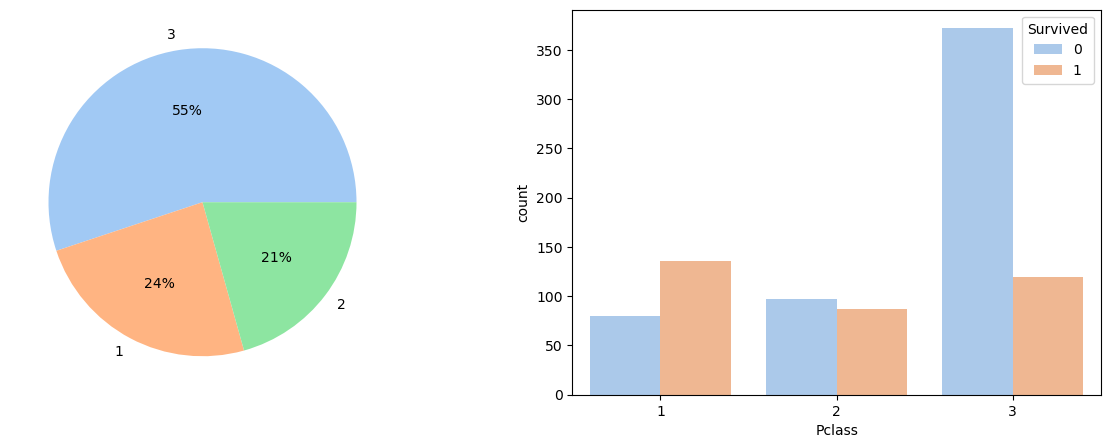

In [21]:
fig, axes = plt.subplots(1,2, figsize = (15, 5))
pclass_count = cleaned_titanic_train['Pclass'].value_counts()
pclass_label = pclass_count.index
axes[0].pie(pclass_count, labels = pclass_label, autopct = '%.0f%%')
sns.countplot(data = cleaned_titanic_train, x = 'Pclass' , hue = 'Survived', ax = axes[1])
plt.show()

由以上饼图可知，数据集中三等舱的乘客最多，占比接近一半，一等舱二等舱乘客数量接近。  
由条形图可知，一等舱的幸存人数多余未幸存人数，二等舱的幸存人数与未幸存人数持平，三等舱幸存人数远少于未幸存人数，即船舱等级越高，幸存比例越大。

### 性别与是否幸存的关系

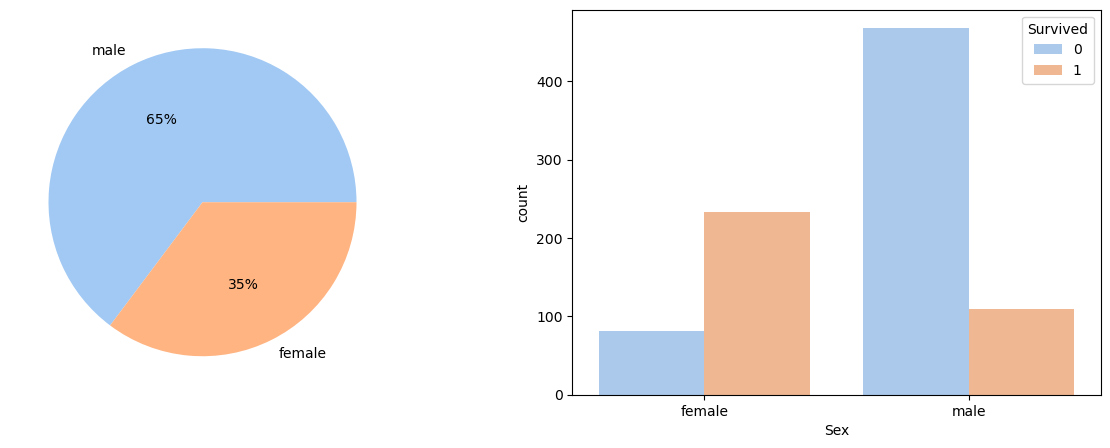

In [22]:
fig, axes = plt.subplots(1,2, figsize = (15, 5))
sex_count = cleaned_titanic_train['Sex'].value_counts()
sex_label = sex_count.index
axes[0].pie(sex_count, labels = sex_label, autopct = '%.0f%%')
sns.countplot(data = cleaned_titanic_train, x = 'Sex' , hue = 'Survived', ax = axes[1])
plt.show()

由以上饼图可知，数据集中男女乘客的比例约为3：2。  
由条形图可知，女性乘客生还的比例大于男性乘客。

### 年龄

#### 年龄分布

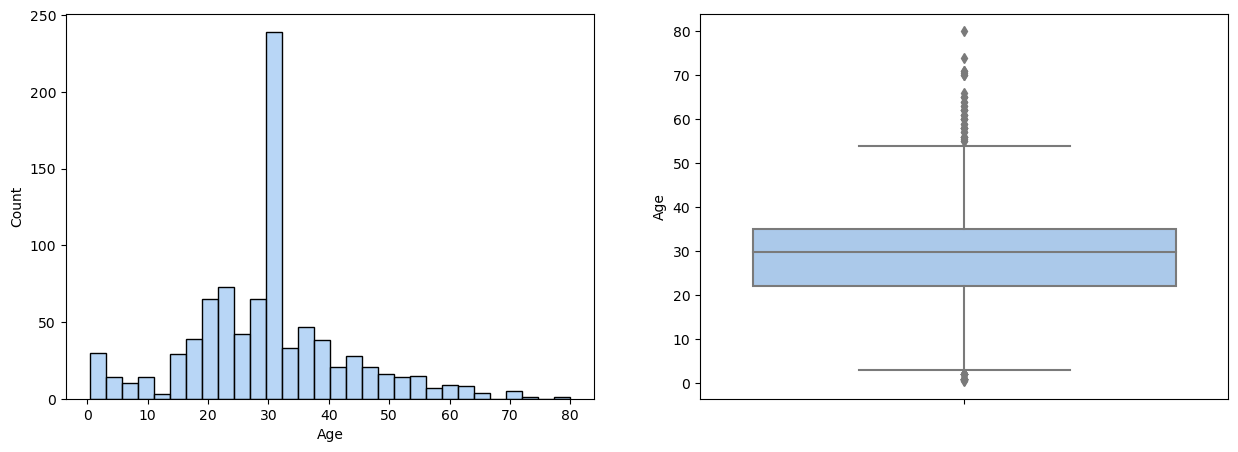

In [23]:
fig, axes = plt.subplots(1,2, figsize = (15, 5))
sns.histplot(cleaned_titanic_train, x = 'Age', ax = axes[0])
sns.boxplot(data = cleaned_titanic_train, y = 'Age', ax = axes[1])
plt.show()

由直方图可知，20-40岁的乘客分布较多，也有一部分20岁以下的青少年和40岁之上的中老年乘客，也有个别数量的低龄儿童和高龄老人。

#### 年龄对是否幸存的影响

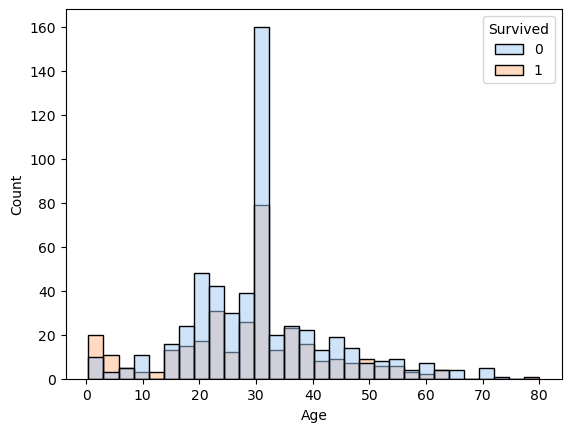

In [24]:
sns.histplot(cleaned_titanic_train, x = 'Age' , hue = 'Survived' , alpha = 0.5)
plt.show()

由以上直方图分类可以看到，数据集cleaned_titanic_train里的低龄儿童幸存比例较高，而其他年龄乘客都是幸存数量少于未幸存数量。

### 家庭成员数量与是否幸存

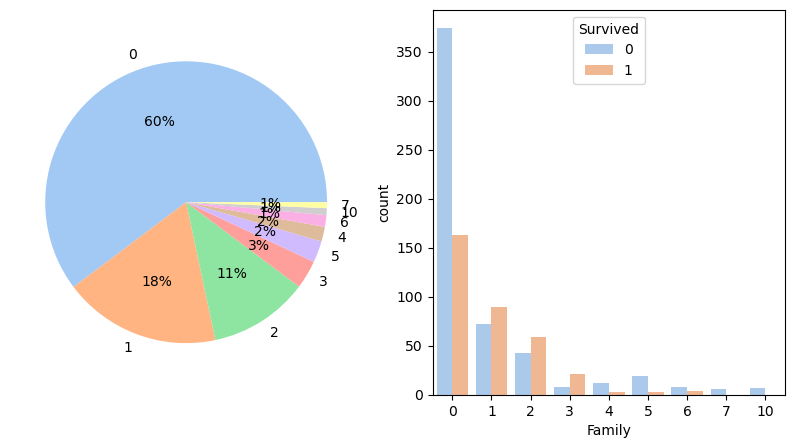

In [25]:
fig, axes = plt.subplots(1, 2, figsize = (10,5))
family_count = cleaned_titanic_train['Family'].value_counts()
family_label = family_count.index
axes[0].pie(family_count, labels = family_label, autopct = '%.0f%%')
sns.countplot(data = cleaned_titanic_train, x = 'Family', hue = 'Survived', ax = axes[1])
plt.show()

由以上饼图可知，0个家庭成员即独身的乘客数量最多，约占60%，带1-3个家庭成员的乘客数量加起来约占比32%，带3以上个家庭成员的乘客占比较少。  
从条形图来看，独身乘客的幸存人数少于未幸存人数，而携带家庭成员数量为1-3的乘客幸存人数占比高于未幸存人数，携带家庭成员人数大于3的乘客幸存人数占比低于未幸存人数。

### 票价金额与是否幸存的关系

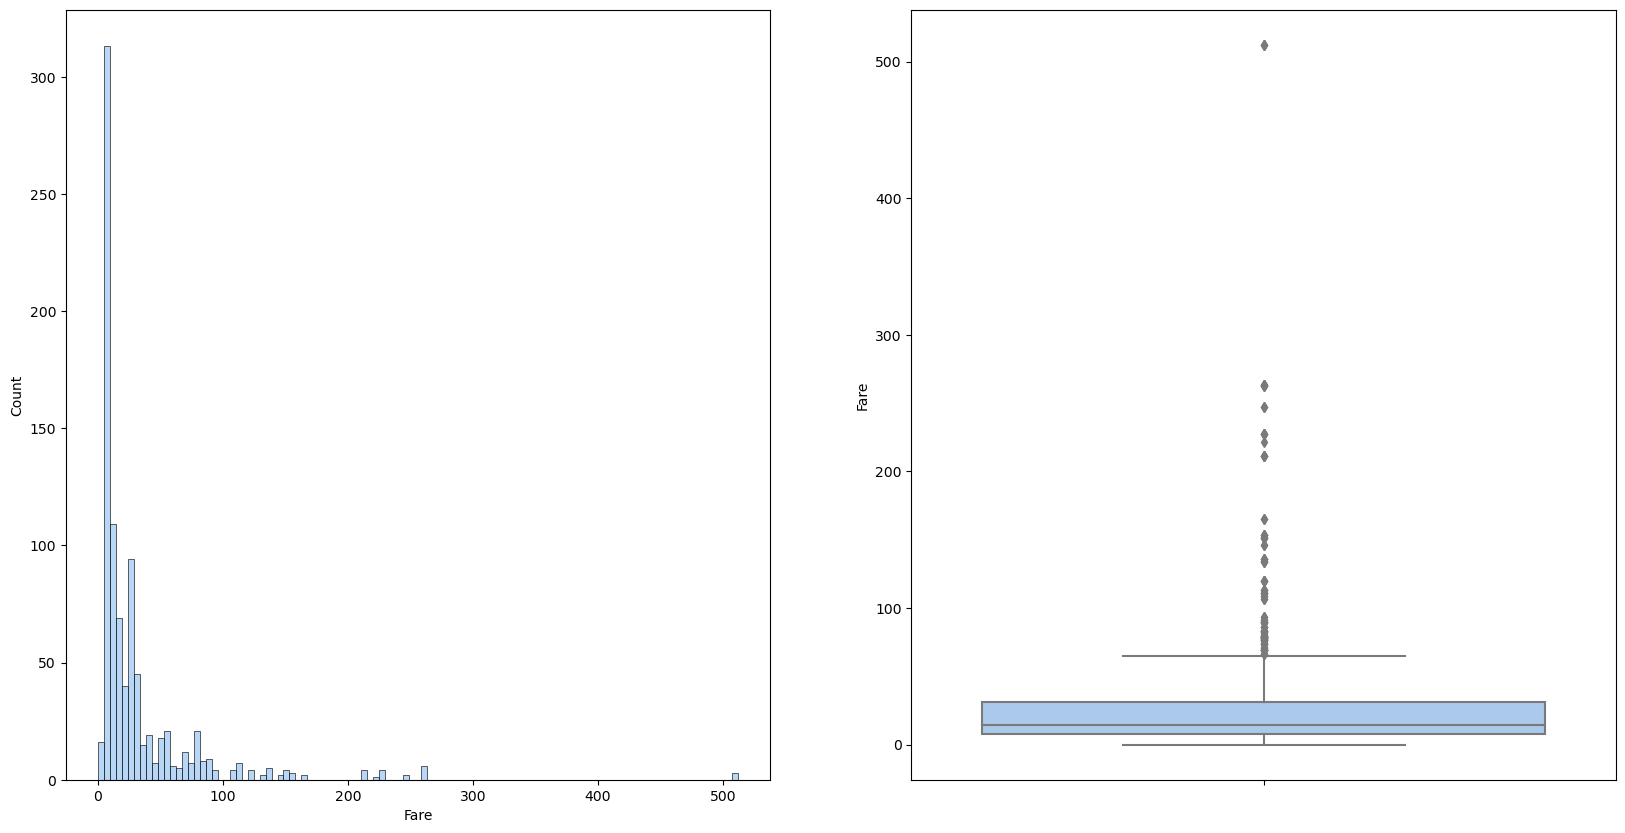

In [26]:
fig, axes = plt.subplots(1, 2, figsize = (20,10))
sns.histplot(cleaned_titanic_train, x = 'Fare', ax = axes[0])
sns.boxplot(data = cleaned_titanic_train, y = 'Fare',ax = axes[1])
plt.show()

从直方图和箱型图来看，绝大多数船票价格在100以内，少量船票价格在100-300之间，还有极个别数量的超高额票价（价格在500以上）。

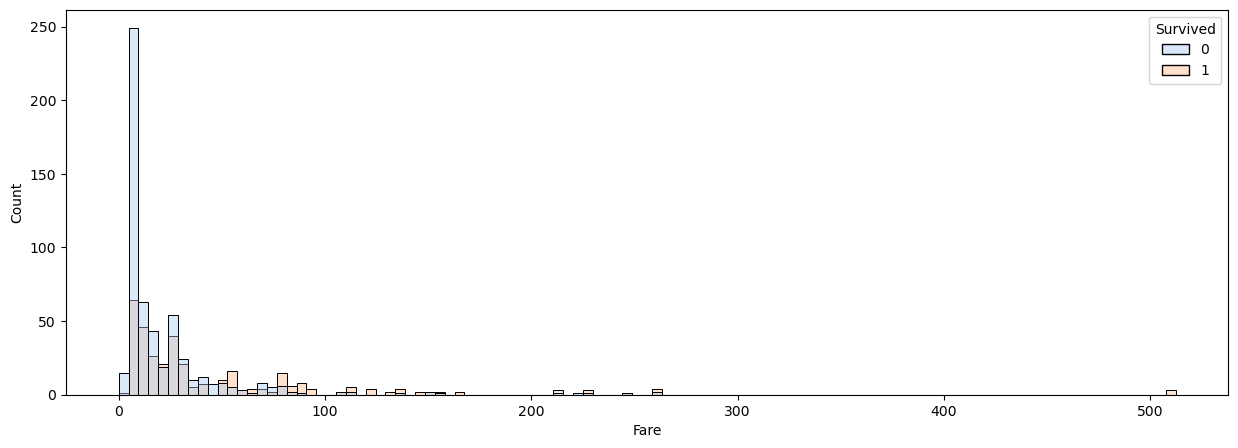

In [27]:
fig,axes = plt.subplots(1,1,figsize = (15,5))
sns.histplot(cleaned_titanic_train, x = 'Fare', hue = 'Survived', alpha = 0.4)
plt.show()

从以上幸存和票价的分类直方图来看，低票价乘客幸存比例较低，高票价乘客幸存比例普遍较高。

### 登陆港口与是否幸存

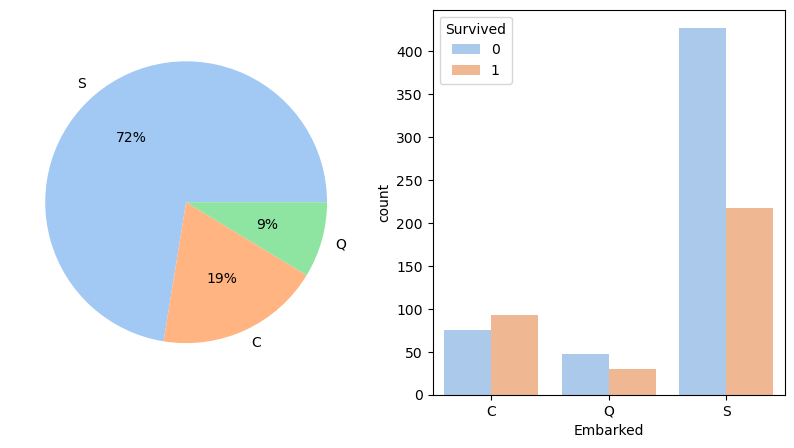

In [28]:
fig, axes = plt.subplots(1, 2, figsize = (10,5))
embarked_count = cleaned_titanic_train['Embarked'].value_counts()
embarked_label = embarked_count.index
axes[0].pie(embarked_count, labels = embarked_label, autopct = '%.0f%%')
sns.countplot(data = cleaned_titanic_train, x = 'Embarked', hue = 'Survived', ax = axes[1])
plt.show()

从饼图来看，从南安普顿登陆的乘客占比最多，大约为72%，从瑟堡登陆的乘客数量第二多，在皇后镇登陆的乘客数量最少。  
从登陆港口和是否幸存分类的条形图看，在瑟堡登陆的乘客幸存人数多余未幸存人数，在南安普顿和皇后镇登陆的乘客人数幸存数量少于未幸存乘客的数量。

## 分析数据

由于本次分析的目的是利用乘客的性别和船舱等级等属性，对幸存情况进行逻辑回归分析，从而利用得到的逻辑回归模型，对未知幸存情况的乘客预测幸存情况。  
因此先引用逻辑回归需要用到的模块。

In [29]:
import statsmodels.api as sm 

接下来创建一个新的DateFrame: lr_titanic_train用来做逻辑回归分析，因为在逻辑回归分析之前，还需要在数据集做引入虚拟变量等准备，因此需要创建新的数据变量将原始数据集区分开来，在新数据lr_titanic_train上进行这些操作。

In [30]:
lr_titanic_train = cleaned_titanic_train.copy()
lr_titanic_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0


移除不会影响幸存概率的变量。

In [31]:
lr_titanic_train = lr_titanic_train.drop(['PassengerId', 'Name', 'Ticket', 'Cabin', 'Embarked'], axis = 1)
lr_titanic_train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Family
0,0,3,male,22.0,1,0,7.2500,1
1,1,1,female,38.0,1,0,71.2833,1
2,1,3,female,26.0,0,0,7.9250,0
3,1,1,female,35.0,1,0,53.1000,1
4,0,3,male,35.0,0,0,8.0500,0


有由于Pclass、Sex都为分类变量，无法直接建立逻辑回归模型，因此需要将它们转换为虚拟变量。

In [32]:
lr_titanic_train = pd.get_dummies(lr_titanic_train, columns = ['Pclass','Sex'], dtype = int, drop_first = True)
lr_titanic_train.head()

,Survived,Age,SibSp,Parch,Fare,Family,Pclass_2,Pclass_3,Sex_male
0,0,22.0,1,0,7.2500,1,0,1,1
1,1,38.0,1,0,71.2833,1,0,0,0
2,1,26.0,0,0,7.9250,0,0,1,0
3,1,35.0,1,0,53.1000,1,0,0,0
4,0,35.0,0,0,8.0500,0,0,1,1


接下来划分自变量和因变量，根据分析目的，因变量为Survived即是否幸存。  
暂时可以将其他变量划分为因变量，但还需要进一步检查这些变量之间的相关性，相关性较高的变量会导致优化算法无法收敛的问题。

In [33]:
y = lr_titanic_train['Survived']
X = lr_titanic_train.drop('Survived', axis = 1)

In [34]:
X.corr().abs()

,Age,SibSp,Parch,Fare,Family,Pclass_2,Pclass_3,Sex_male
Age,1.000000,0.232625,0.179191,0.091566,0.248512,0.006589,0.281004,0.084153
SibSp,0.232625,1.000000,0.414838,0.159651,0.890712,0.055932,0.092548,0.114631
Parch,0.179191,0.414838,1.000000,0.216225,0.783111,0.000734,0.015790,0.245489
Fare,0.091566,0.159651,0.216225,1.000000,0.217138,0.118557,0.413333,0.182333
Family,0.248512,0.890712,0.783111,0.217138,1.000000,0.038594,0.071142,0.200988
Pclass_2,0.006589,0.055932,0.000734,0.118557,0.038594,1.000000,0.565210,0.064746
Pclass_3,0.281004,0.092548,0.015790,0.413333,0.071142,0.565210,1.000000,0.137143
Sex_male,0.084153,0.114631,0.245489,0.182333,0.200988,0.064746,0.137143,1.000000


检查变量之间相关性，要看变量之间的相关系数绝对值是否大于0.8，若大于0.8就说明相关性较高，因此需要找出之间相关性绝对值大于0.8的变量。

In [35]:
X.corr().abs() > 0.8

,Age,SibSp,Parch,Fare,Family,Pclass_2,Pclass_3,Sex_male
Age,True,False,False,False,False,False,False,False
SibSp,False,True,False,False,True,False,False,False
Parch,False,False,True,False,False,False,False,False
Fare,False,False,False,True,False,False,False,False
Family,False,True,False,False,True,False,False,False
Pclass_2,False,False,False,False,False,True,False,False
Pclass_3,False,False,False,False,False,False,True,False
Sex_male,False,False,False,False,False,False,False,True


可以看出，Family和SibSp和之间的相关系数大于0.8，因为Family是SibSp和Parch相加的结果，这是在意料之中的。而相关性较高的变量会导致优化算法无法收敛，得到的模型参数不准确，因此需要将其中一个变量移除。选择保留Family，移除SibSp变量。  
另外发现，Parch变量移除和Family之间的相关系数为0.783111，比较接近0.8，因此需要将Parch变量移除。

In [36]:
X = X.drop(['SibSp','Parch'],axis = 1)
X

,Age,Fare,Family,Pclass_2,Pclass_3,Sex_male
0,22.000000,7.2500,1,0,1,1
1,38.000000,71.2833,1,0,0,0
2,26.000000,7.9250,0,0,1,0
3,35.000000,53.1000,1,0,0,0
4,35.000000,8.0500,0,0,1,1
...,...,...,...,...,...,...
886,27.000000,13.0000,0,1,0,1
887,19.000000,30.0000,0,0,0,0
888,29.699118,23.4500,3,0,1,0
889,26.000000,30.0000,0,0,0,1


还需要在自变量中添加截距。

In [37]:
X = sm.add_constant(X)
X

,const,Age,Fare,Family,Pclass_2,Pclass_3,Sex_male
0,1.0,22.000000,7.2500,1,0,1,1
1,1.0,38.000000,71.2833,1,0,0,0
2,1.0,26.000000,7.9250,0,0,1,0
3,1.0,35.000000,53.1000,1,0,0,0
4,1.0,35.000000,8.0500,0,0,1,1
...,...,...,...,...,...,...,...
886,1.0,27.000000,13.0000,0,1,0,1
887,1.0,19.000000,30.0000,0,0,0,0
888,1.0,29.699118,23.4500,3,0,1,0
889,1.0,26.000000,30.0000,0,0,0,1


接下来就可以调用Logit函数，利用最大似然优化建立逻辑回归模型，并得到模型的汇总信息。

In [38]:
result = sm.Logit(y, X).fit()
result.summary()

Optimization terminated successfully.
         Current function value: 0.443547
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               Survived   No. Observations:                  891
Model:                          Logit   Df Residuals:                      884
Method:                           MLE   Df Model:                            6
Date:                Mon, 25 Aug 2025   Pseudo R-squ.:                  0.3339
Time:                        21:37:30   Log-Likelihood:                -395.20
converged:                       True   LL-Null:                       -593.33
Covariance Type:            nonrobust   LLR p-value:                 1.786e-82
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.8097      0.445      8.568      0.000       2.938       4.681
Age           -0.0388      0.008     -4.963      0.000      -0.054      -0.023
Fare           0.0032      0.002      1.311      0.190      -0.002       0.008
Family        -0.2430      0.068     -3.594      0.000      -0.376      -0.110
Pclass_2      -1.0003      0.293     -3.416      0.001      -1.574      -0.426
Pclass_3      -2.1324      0.289     -7.373      0.000      -2.699      -1.566
Sex_male      -2.7759      0.199    -13.980      0.000      -3.165      -2.387
==============================================================================
"""

将显著水平设定为0.05，即P值小于0.05，就说明该自变量对因变量有显著预测作用，P值大于0.05，就说明该自变量对因变量没有显著预测作用。  
从以上汇总信息可以看到，Fare变量的P值大于0.05，对因变量没有显著预测作品，需要移除后重新建立逻辑回归模型。

In [39]:
X = X.drop('Fare', axis = 1)

In [40]:
result = sm.Logit(y,X).fit()
result.summary()

Optimization terminated successfully.
         Current function value: 0.444623
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               Survived   No. Observations:                  891
Model:                          Logit   Df Residuals:                      885
Method:                           MLE   Df Model:                            5
Date:                Mon, 25 Aug 2025   Pseudo R-squ.:                  0.3323
Time:                        21:37:30   Log-Likelihood:                -396.16
converged:                       True   LL-Null:                       -593.33
Covariance Type:            nonrobust   LLR p-value:                 4.927e-83
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.0620      0.404     10.049      0.000       3.270       4.854
Age           -0.0395      0.008     -5.065      0.000      -0.055      -0.024
Family        -0.2186      0.065     -3.383      0.001      -0.345      -0.092
Pclass_2      -1.1798      0.261     -4.518      0.000      -1.692      -0.668
Pclass_3      -2.3458      0.242     -9.676      0.000      -2.821      -1.871
Sex_male      -2.7854      0.198    -14.069      0.000      -3.173      -2.397
==============================================================================
"""

从模型的参数可以看到，Age、Family、Pclass_2、Pclass_、Sex_male这些变量数值的增加或者存在会降低乘客幸存的概率。  
计算自然常数的次方可以了解这些变量系数的含义。

In [41]:
#Age
np.exp(-0.0395)

0.9612699539905982

即年龄每增加1岁，幸存概率是原来的0.96倍，即降低0.04。

In [42]:
#Family
np.exp(-0.2186)

0.803643111115195

即同乘的家庭成员每增加1人，乘客幸存的概率就变成原来的0.8倍，即降低约20%。

In [43]:
#Pclass_2
np.exp(-1.1798)

0.30734020049483596

说明二等舱乘客幸存的概率是一等舱的0.3倍，即二等舱乘客幸存的概率较一等舱乘客降低70%。

In [44]:
#Pclass_3
np.exp(-2.3458)

0.09577055503172162

说明三等舱的乘客幸存的概率不到一等舱乘客的10%，即比一等舱乘客幸存的概率降低90%以上。

In [45]:
np.exp(-2.7854)

0.061704402333015156

说明男性乘客幸存的概率是女性乘客的6%左右。

根据模型参数总结为：  
- 年龄越小生还的概率越高  
- 同乘家庭成员越少的乘客生还概率越高  
- 船舱等级越高的乘客生还概率越高  
- 女性乘客生还概率远高于男性乘客

第一条和第四条的原因可能是由于泰坦尼克号沉船时，乘客坚持优先让女性和孩子逃生的原则。  
第二条可能是因为同乘家庭成员较多的乘客在逃生时因为解救其他家人，从而失去了逃生的机会。
第三条的原因可能是等级越高的船舱逃生的条件越优先。

得到逻辑回归模型后，就可以使用未知幸存情况的乘客数据titanic_test.csv，根据乘客属性对幸存情况进行预测。

读取titanic_test.csv数据，并将其赋值给变量lr_titanic_test作为预测数据。

In [46]:
lr_titanic_test = pd.read_csv('titanic_test.csv')
lr_titanic_test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


检查是否有缺失值。

In [47]:
lr_titanic_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


lr_titanic_test数据共有418行观察值，其中Age、Fare、Cabin列含有缺失值，而Fare和Cabin不属于逻辑回归模型的自变量，因此可以不处理这些缺失值。而Age表示年龄，是进行逻辑回归预测的必要自变量，因此需要将Age的空缺值用平均值填充。

In [48]:
lr_titanic_test['Age'] = lr_titanic_test['Age'].fillna(lr_titanic_test['Age'].mean())
lr_titanic_test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.50000,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.00000,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.00000,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.00000,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.00000,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,30.27259,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.00000,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.50000,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,30.27259,0,0,359309,8.0500,NaN,S


检查重复数据：根据每个变量的含义，PassengerId即乘客ID变量不允许有重复数据。

In [49]:
lr_titanic_test['PassengerId'].duplicated().sum()

0

以上重复数据求和为0，即PassengerId列没有重复数据。

检查不一致数据：分类变量可能存在不一致数据，即出现不同值指代同一目标的情况，有可能会影响到后续的幸存情况预测，因此需要对这些变量检查。

In [50]:
lr_titanic_test['Pclass'].value_counts()

3    218
1    107
2     93
Name: Pclass, dtype: int64

In [51]:
lr_titanic_test['Sex'].value_counts()

male      266
female    152
Name: Sex, dtype: int64

In [52]:
lr_titanic_test['Embarked'].value_counts()

S    270
C    102
Q     46
Name: Embarked, dtype: int64

以上可知，lr_titanic_test中不存在不一致数据。

在lr_titanic_test的分类数据中引入虚拟变量，但在引入虚拟变量之前，需要调用Categorical方法将它们的数据类型转换为Category，并使用categories让程序知道所有可能的分类，因为lr_titanic_test包含的分类可能不全，直接引入虚拟变量可能会漏掉某个分类。

In [53]:
lr_titanic_test['Pclass'] = pd.Categorical(lr_titanic_test['Pclass'], categories = ['1','2','3'])
lr_titanic_test['Sex'] = pd.Categorical(lr_titanic_test['Sex'], categories = ['female','male'])
lr_titanic_test['Embarked'] = pd.Categorical(lr_titanic_test['Embarked'], categories = ['Q','S','C'])

In [54]:
lr_titanic_test = pd.get_dummies(lr_titanic_test, columns = ['Pclass','Sex','Embarked'], dtype = int,
                                drop_first = True)
lr_titanic_test

,PassengerId,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Pclass_2,Pclass_3,Sex_male,Embarked_S,Embarked_C
0,892,"Kelly, Mr. James",34.50000,0,0,330911,7.8292,NaN,0,0,1,0,0
1,893,"Wilkes, Mrs. James (Ellen Needs)",47.00000,1,0,363272,7.0000,NaN,0,0,0,1,0
2,894,"Myles, Mr. Thomas Francis",62.00000,0,0,240276,9.6875,NaN,0,0,1,0,0
3,895,"Wirz, Mr. Albert",27.00000,0,0,315154,8.6625,NaN,0,0,1,1,0
4,896,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",22.00000,1,1,3101298,12.2875,NaN,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,"Spector, Mr. Woolf",30.27259,0,0,A.5. 3236,8.0500,NaN,0,0,1,1,0
414,1306,"Oliva y Ocana, Dona. Fermina",39.00000,0,0,PC 17758,108.9000,C105,0,0,0,0,1
415,1307,"Saether, Mr. Simon Sivertsen",38.50000,0,0,SOTON/O.Q. 3101262,7.2500,NaN,0,0,1,1,0
416,1308,"Ware, Mr. Frederick",30.27259,0,0,359309,8.0500,NaN,0,0,1,1,0


由于我们之前建立了Family变量，因此需要在预测数据中添加这个变量。

In [55]:
lr_titanic_test['Family'] = lr_titanic_test['SibSp'] + lr_titanic_test['Parch']
lr_titanic_test.head()

,PassengerId,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Pclass_2,Pclass_3,Sex_male,Embarked_S,Embarked_C,Family
0,892,"Kelly, Mr. James",34.5,0,0,330911,7.8292,NaN,0,0,1,0,0,0
1,893,"Wilkes, Mrs. James (Ellen Needs)",47.0,1,0,363272,7.0000,NaN,0,0,0,1,0,1
2,894,"Myles, Mr. Thomas Francis",62.0,0,0,240276,9.6875,NaN,0,0,1,0,0,0
3,895,"Wirz, Mr. Albert",27.0,0,0,315154,8.6625,NaN,0,0,1,1,0,0
4,896,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",22.0,1,1,3101298,12.2875,NaN,0,0,0,1,0,2


In [56]:
result.params

const       4.061982
Age        -0.039495
Family     -0.218627
Pclass_2   -1.179763
Pclass_3   -2.345823
Sex_male   -2.785398
dtype: float64

由于输入逻辑回归模型的预测变量应该与模型中的自变量保持一致，因此需要在预测数据lr_titanic_test中筛选出与回归模型自变量一致的自变量。

In [57]:
lr_titanic_test = lr_titanic_test[['Age','Pclass_2','Pclass_3','Sex_male','Family']]
lr_titanic_test.head()

,Age,Pclass_2,Pclass_3,Sex_male,Family
0,34.5,0,0,1,0
1,47.0,0,0,0,1
2,62.0,0,0,1,0
3,27.0,0,0,1,0
4,22.0,0,0,0,2


给筛选出的自变量添加截距。

In [58]:
X_titanic_test = sm.add_constant(lr_titanic_test)
X_titanic_test.head()

,const,Age,Pclass_2,Pclass_3,Sex_male,Family
0,1.0,34.5,0,0,1,0
1,1.0,47.0,0,0,0,1
2,1.0,62.0,0,0,1,0
3,1.0,27.0,0,0,1,0
4,1.0,22.0,0,0,0,2


接下来就可以将上面整理后的预测变量输入模型，对幸存情况进行预测。

In [59]:
survived_predict = result.predict(X_titanic_test)
survived_predict

0      0.587485
1      0.359005
2      0.324638
3      0.656963
4      0.084889
         ...   
413    0.627274
414    0.925647
415    0.548744
416    0.627274
417    0.006367
Length: 418, dtype: float64

以上就是利用逻辑回归模型对数据集titianic_train.csv预测的乘客幸存概率。我们将概率大于0.5设定为幸存，将概率小于等于0.5设定为未幸存。

In [60]:
survived_predict > 0.5

0       True
1      False
2      False
3       True
4      False
       ...  
413     True
414     True
415     True
416     True
417    False
Length: 418, dtype: bool

以上布尔值的series中，True表示为幸存，False表示为未幸存。